In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

In [3]:
print(f'TensorFlow version: {tf.__version__}')
print(f'Keras version : {keras.__version__}')

gpus = tf.config.list_physical_devices('GPU')
print(f'GPUs available: {len(gpus)}')

TensorFlow version: 2.21.0
Keras version : 3.14.1
GPUs available: 0


In [5]:
# Load MNIST — automatically downloads on first run
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

print('=== MNIST Dataset Info ===')

print(f'Training images : {X_train.shape}')
print(f'Training labels : {y_train.shape}')

print(f'Test images : {X_test.shape}')
print(f'Test labels : {y_test.shape}')

print(f'Pixel value range: {X_train.min()} to {X_train.max()}')

print(f'Unique classes : {sorted(set(y_train.tolist()))}')

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
=== MNIST Dataset Info ===
Training images : (60000, 28, 28)
Training labels : (60000,)
Test images : (10000, 28, 28)
Test labels : (10000,)
Pixel value range: 0 to 255
Unique classes : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


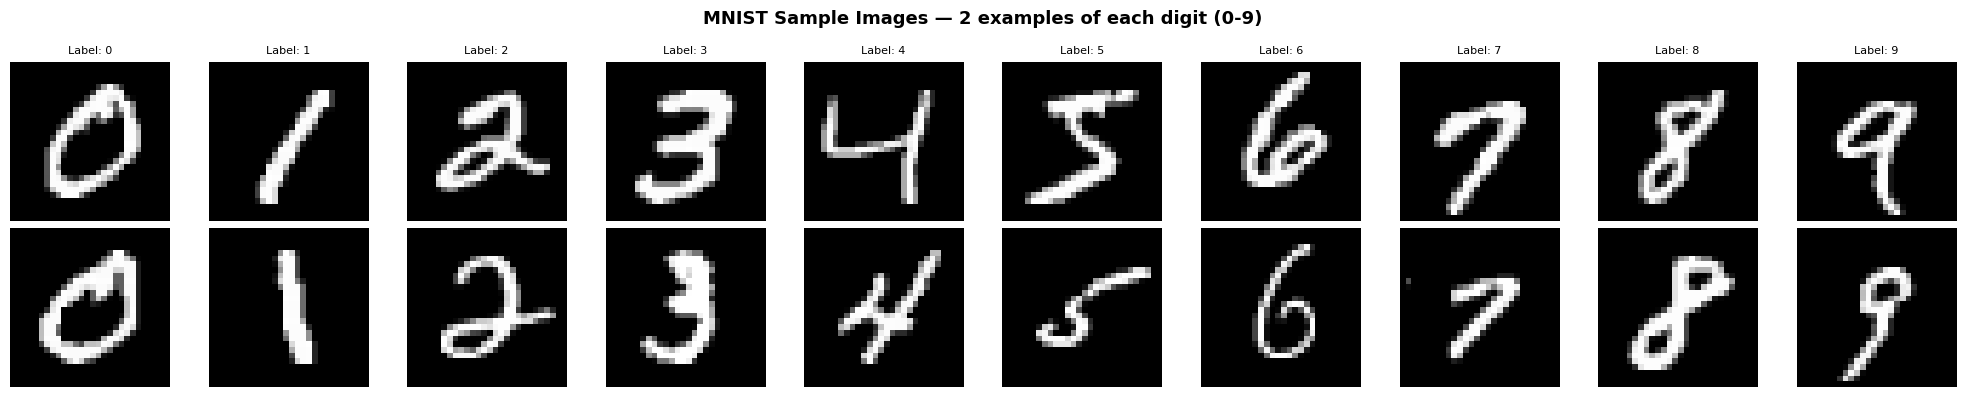

In [7]:
fig, axes = plt.subplots(2, 10, figsize=(20, 4))

for digit in range(10):

    idx = np.where(y_train == digit)[0][0]

    axes[0, digit].imshow(X_train[idx], cmap='gray')
    axes[0, digit].set_title(f'Label: {digit}', fontsize=8)
    axes[0, digit].axis('off')

    idx2 = np.where(y_train == digit)[0][1]

    axes[1, digit].imshow(X_train[idx2], cmap='gray')
    axes[1, digit].axis('off')

plt.suptitle(
    'MNIST Sample Images — 2 examples of each digit (0-9)',
    fontsize=13,
    fontweight='bold'
)

plt.tight_layout()

plt.savefig('mnist_samples.png', dpi=150, bbox_inches='tight')

plt.show()

In [9]:
# Step 1: Normalise pixel values from [0,255] to [0.0, 1.0]

X_train_norm = X_train.astype('float32') / 255.0
X_test_norm = X_test.astype('float32') / 255.0

In [11]:
# Step 2: Reshape — CNNs expect (batch, height, width, channels)

X_train_cnn = X_train_norm.reshape(-1, 28, 28, 1)

X_test_cnn = X_test_norm.reshape(-1, 28, 28, 1)

print(f'Shape after reshape: {X_train_cnn.shape}')

Shape after reshape: (60000, 28, 28, 1)


In [13]:
# Step 3: One-hot encode labels

y_train_ohe = to_categorical(y_train, num_classes=10)

y_test_ohe = to_categorical(y_test, num_classes=10)

print(f'Label before one-hot: {y_train[0]}')

print(f'Label after one-hot : {y_train_ohe[0]}')

Label before one-hot: 5
Label after one-hot : [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


In [15]:
def build_cnn(input_shape=(28,28,1), num_classes=10):

    model = models.Sequential([

        # BLOCK 1

        layers.Conv2D(
            filters=32,
            kernel_size=(3,3),
            activation='relu',
            padding='same',
            input_shape=input_shape,
            name='conv1'
        ),

        layers.BatchNormalization(),

        layers.Conv2D(
            32,
            (3,3),
            activation='relu',
            padding='same',
            name='conv2'
        ),

        layers.MaxPooling2D(
            pool_size=(2,2),
            name='pool1'
        ),

        layers.Dropout(0.25),

        # BLOCK 2

        layers.Conv2D(
            64,
            (3,3),
            activation='relu',
            padding='same',
            name='conv3'
        ),

        layers.BatchNormalization(),

        layers.Conv2D(
            64,
            (3,3),
            activation='relu',
            padding='same',
            name='conv4'
        ),

        layers.MaxPooling2D(
            pool_size=(2,2),
            name='pool2'
        ),

        layers.Dropout(0.25),

        # CLASSIFIER

        layers.Flatten(name='flatten'),

        layers.Dense(
            256,
            activation='relu',
            name='dense1'
        ),

        layers.BatchNormalization(),

        layers.Dropout(0.5),

        layers.Dense(
            num_classes,
            activation='softmax',
            name='output'
        )

    ])

    return model

In [23]:
model = build_cnn()

In [25]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                       │ (None, 28, 28, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_9                │ (None, 28, 28, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2 (Conv2D)                       │ (None, 28, 28, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ pool1 (MaxPooling2D)                 │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_9 (Dropout)                  │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv3 (Conv2D)                       │ (None, 14, 14, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_10               │ (None, 14, 14, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv4 (Conv2D)                       │ (None, 14, 14, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ pool2 (MaxPooling2D)                 │ (None, 7, 7, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_10 (Dropout)                 │ (None, 7, 7, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 3136)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense1 (Dense)                       │ (None, 256)                 │         803,072 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_11               │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_11 (Dropout)                 │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ output (Dense)                       │ (None, 10)                  │           2,570 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 872,042 (3.33 MB)

 Trainable params: 871,338 (3.32 MB)

 Non-trainable params: 704 (2.75 KB)

In [27]:
# Compile: set optimizer, loss function, and metrics

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [29]:
callbacks = [

    EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True
    ),

    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7
    )

]

In [31]:
print('Training CNN on MNIST...')

history = model.fit(

    X_train_cnn,
    y_train_ohe,

    epochs=20,

    batch_size=128,

    validation_split=0.15,

    callbacks=callbacks,

    verbose=1
)

print('\nTraining complete!')

print(f'Epochs trained: {len(history.history["accuracy"])}')

Training CNN on MNIST...
Epoch 1/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 55s 123ms/step - accuracy: 0.9372 - loss: 0.2047 - val_accuracy: 0.3144 - val_loss: 3.3107 - learning_rate: 0.0010
Epoch 2/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 47s 117ms/step - accuracy: 0.9784 - loss: 0.0688 - val_accuracy: 0.9882 - val_loss: 0.0428 - learning_rate: 0.0010
Epoch 3/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 49s 122ms/step - accuracy: 0.9837 - loss: 0.0515 - val_accuracy: 0.9888 - val_loss: 0.0405 - learning_rate: 0.0010
Epoch 4/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 47s 118ms/step - accuracy: 0.9856 - loss: 0.0446 - val_accuracy: 0.9912 - val_loss: 0.0324 - learning_rate: 0.0010
Epoch 5/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 48s 119ms/step - accuracy: 0.9875 - loss: 0.0388 - val_accuracy: 0.9903 - val_loss: 0.0319 - learning_rate: 0.0010
Epoch 6/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 48s 119ms/step - accuracy: 0.9904 - loss: 0.0308 - val_accuracy: 0.9919 - val_loss: 0.0267 - learning_rate: 0.0010
Epoch 7/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 47s 1

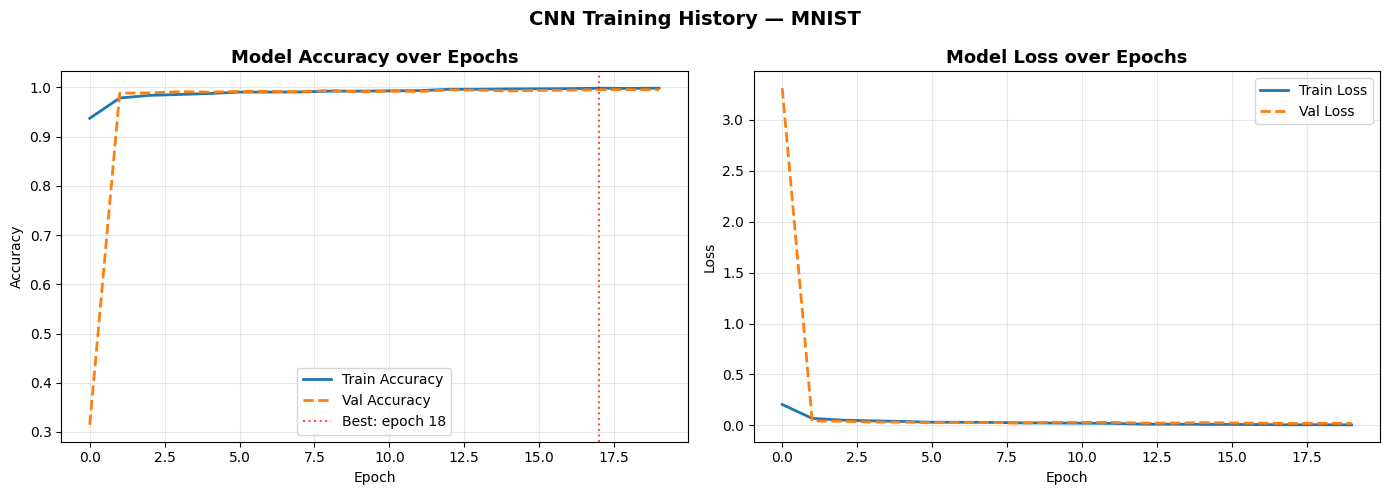

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
axes[0].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)

axes[0].plot(
    history.history['val_accuracy'],
    label='Val Accuracy',
    linewidth=2,
    linestyle='--'
)

axes[0].set_title(
    'Model Accuracy over Epochs',
    fontweight='bold',
    fontsize=13
)

axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')

axes[0].legend()
axes[0].grid(alpha=0.3)

best_ep = history.history['val_accuracy'].index(
    max(history.history['val_accuracy'])
)

axes[0].axvline(
    best_ep,
    color='red',
    linestyle=':',
    alpha=0.7,
    label=f'Best: epoch {best_ep+1}'
)

axes[0].legend()

# Loss plot

axes[1].plot(
    history.history['loss'],
    label='Train Loss',
    linewidth=2
)

axes[1].plot(
    history.history['val_loss'],
    label='Val Loss',
    linewidth=2,
    linestyle='--'
)

axes[1].set_title(
    'Model Loss over Epochs',
    fontweight='bold',
    fontsize=13
)

axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')

axes[1].legend()

axes[1].grid(alpha=0.3)

plt.suptitle(
    'CNN Training History — MNIST',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()

plt.savefig(
    'cnn_training_history.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

In [35]:
test_loss, test_acc = model.evaluate(
    X_test_cnn,
    y_test_ohe,
    verbose=0
)

print(f'Test Accuracy: {test_acc*100:.2f}%')

print(f'Test Loss : {test_loss:.4f}')

Test Accuracy: 99.57%
Test Loss : 0.0141


In [37]:
y_pred_probs = model.predict(X_test_cnn)

y_pred = np.argmax(y_pred_probs, axis=1)

y_true = y_test

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step


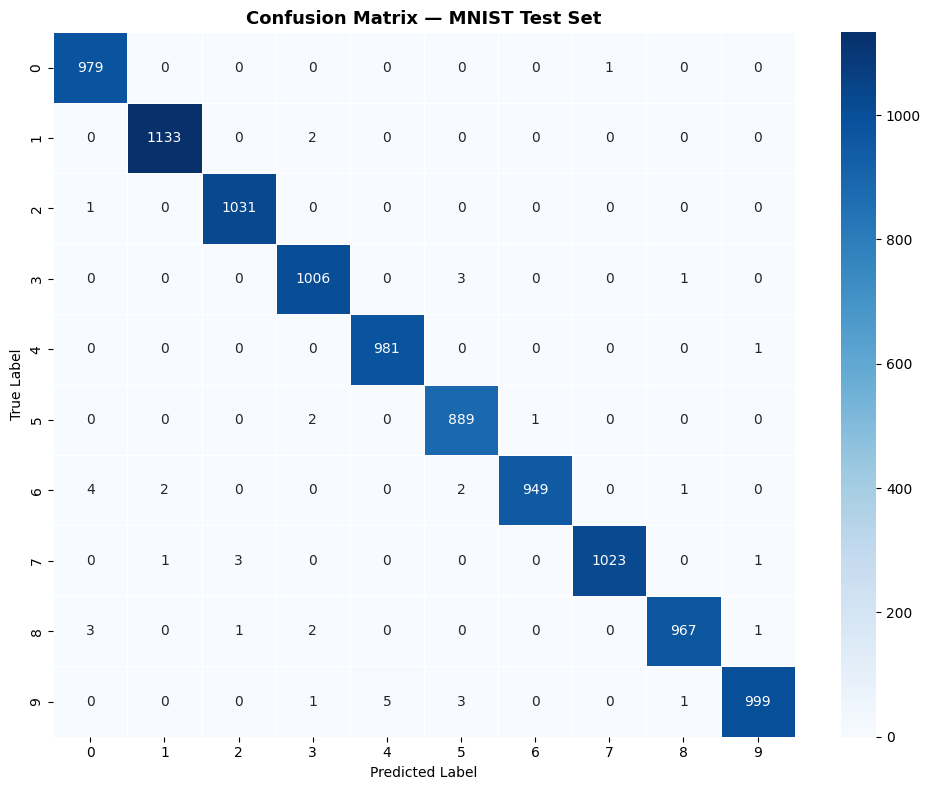

In [39]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=range(10),
    yticklabels=range(10),
    linewidths=0.5
)

plt.title(
    'Confusion Matrix — MNIST Test Set',
    fontsize=13,
    fontweight='bold'
)

plt.ylabel('True Label')

plt.xlabel('Predicted Label')

plt.tight_layout()

plt.savefig(
    'mnist_confusion_matrix.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

Total misclassified: 43 / 10000


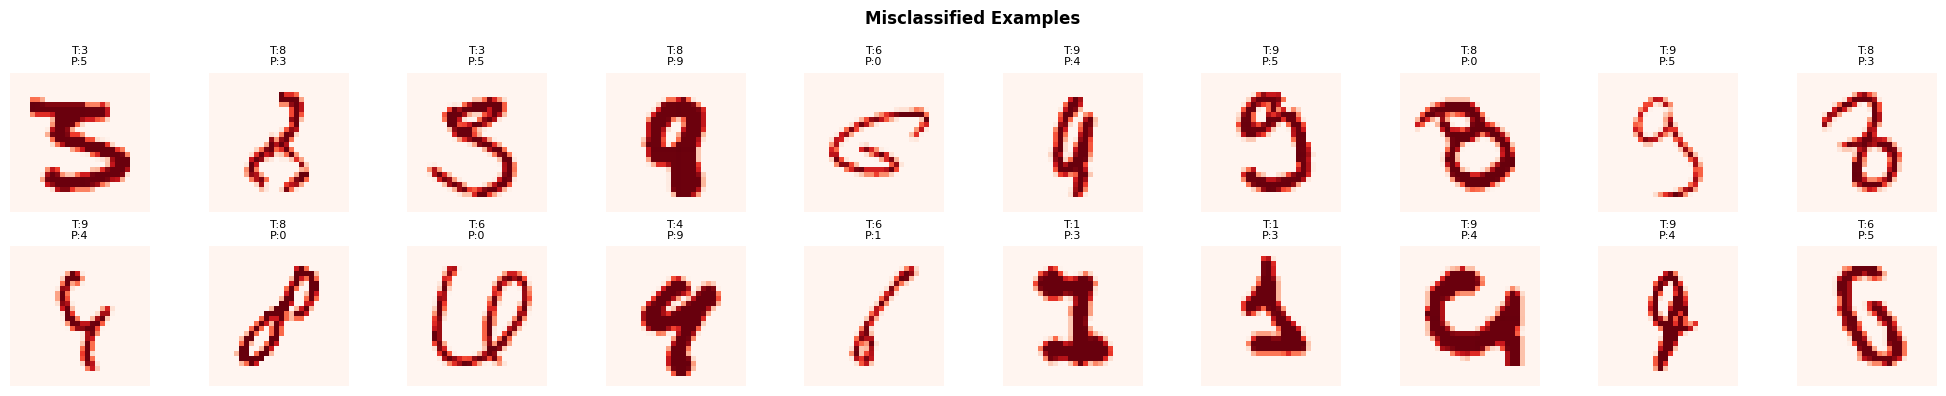

In [41]:
wrong_idx = np.where(y_pred != y_true)[0]

print(
    f'Total misclassified: {len(wrong_idx)} / {len(y_true)}'
)

fig, axes = plt.subplots(2,10, figsize=(20,4))

for i, idx in enumerate(wrong_idx[:20]):

    ax = axes[i//10, i%10]

    ax.imshow(X_test[idx], cmap='Reds')

    ax.set_title(
        f'T:{y_true[idx]}\nP:{y_pred[idx]}',
        fontsize=8
    )

    ax.axis('off')

plt.suptitle(
    'Misclassified Examples',
    fontweight='bold'
)

plt.tight_layout()

plt.savefig(
    'mnist_errors.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()